# 1. IMPORTAÇÃO DE BIBLIOTECAS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp


# 2. PARÂMETROS DO MODELO E DA ASSIMILAÇÃO


In [ ]:
# Parâmetros clássicos do modelo de Lorenz-63 (sistema caótico)
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0

# Configurações do ciclo de assimilação
P_AD = 10     # Frequência: realizar assimilação a cada 10 passos de tempo
N_AD = 30     # Número total de janelas de assimilação
num_steps = 2000 # Total de passos da simulação
dt = 0.01     # Passo de tempo para o Runge-Kutta (Modelo de Lorenz)
dt_euler = 0.001 # Passo de tempo menor para a integração da CeNN (garante estabilidade)

# Parâmetros da Rede Neural Celular (CeNN)
I_CNN = 100   # Iterações da CeNN por ciclo de assimilação
Bias = 0      # Viés da rede (I na equação diferencial)
eps1 = 10e-2  # Valor de segurança para evitar divisão por zero


# 3. DEFINIÇÃO DAS EQUAÇÕES E MÉTODOS DE INTEGRAÇÃO


In [ ]:
def lorenz_63(t, state):
    """ Define as equações diferenciais do atrator de Lorenz. """
    x, y, z = state
    dx_dt = sigma * (y - x)
    dy_dt = x * (rho - z) - y
    dz_dt = x * y - beta * z
    return np.array([dx_dt, dy_dt, dz_dt])

def runge_kutta(f, t, dt, y):
    """ Implementação manual do método de Runge-Kutta de 4ª ordem (RK4).
        Oferece maior precisão que o método de Euler simples para sistemas dinâmicos. """
    k1 = dt * f(t, y)
    k2 = dt * f(t + 0.5 * dt, y + 0.5 * k1)
    k3 = dt * f(t + 0.5 * dt, y + 0.5 * k2)
    k4 = dt * f(t + dt, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

# Matrizes para armazenar os resultados
t_values = np.zeros(num_steps)
xr_values = np.zeros(num_steps)
yr_values = np.zeros(num_steps)
zr_values = np.zeros(num_steps)

# 4. GERAÇÃO DE OBSERVAÇÕES SINTÉTICAS E MODELO COM RUÍDO


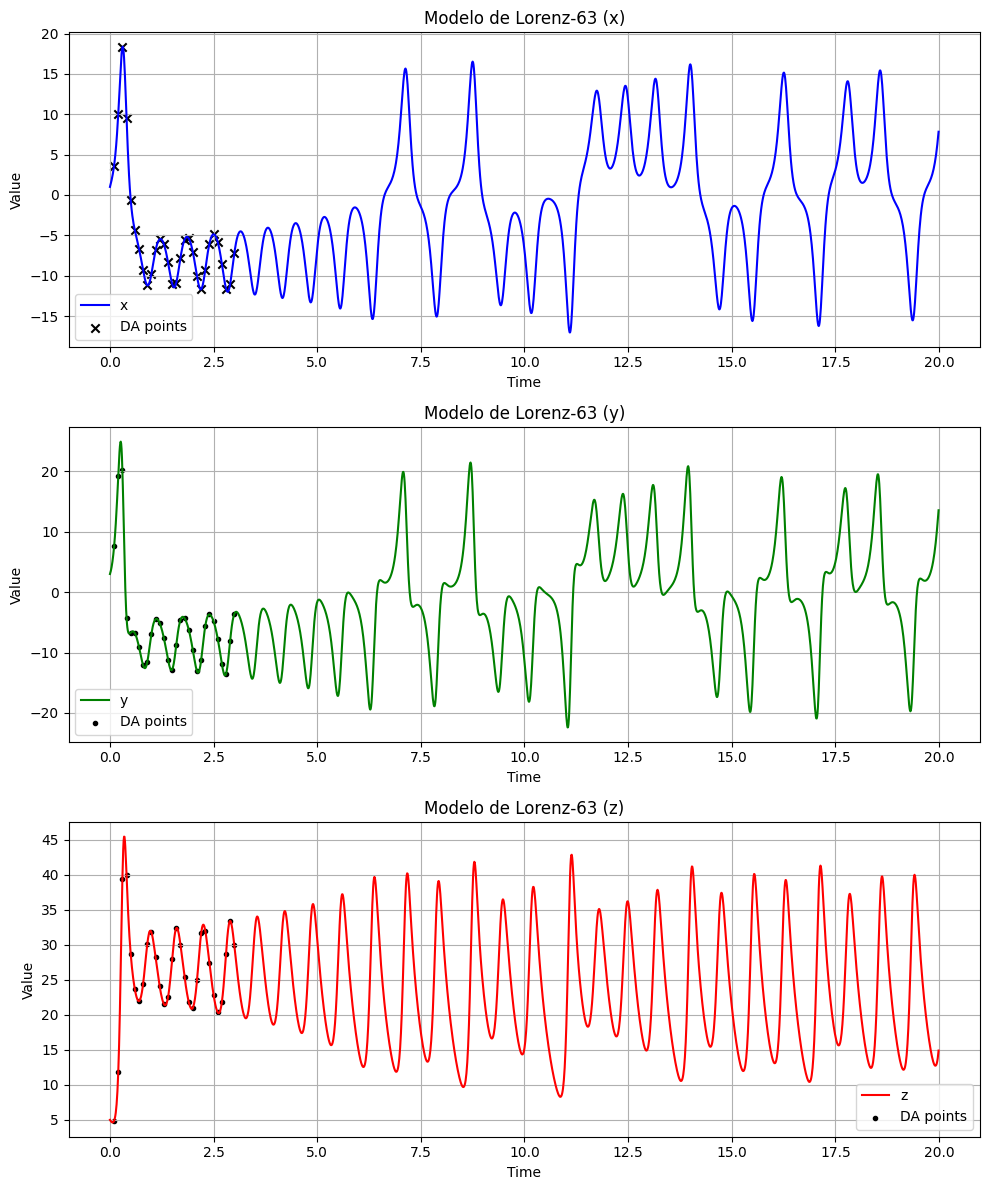

In [ ]:
# O estado inicial do sistema 'verdadeiro'
state = np.array([1.0, 3.0, 5.0])
obs_points = [P_AD * w for w in range(1, N_AD + 1)] # Definindo os instantes de observação
obs = [[], [], []]

# Inicializando arrays para armazenar a trajetória real
t_values = np.zeros(num_steps)
xr_values = np.zeros(num_steps)
yr_values = np.zeros(num_steps)
zr_values = np.zeros(num_steps)

for i in range(num_steps):
    # Armazenando observações sintéticas nos pontos pré-definidos
    for k in range(N_AD):
        if i == obs_points[k]:
            obs[0].append(state[0])
            obs[1].append(state[1])
            obs[2].append(state[2])

    t_values[i] = i * dt
    xr_values[i], yr_values[i], zr_values[i] = state
    state = runge_kutta(lorenz_63, i * dt, dt, state)

# Crie a figura e os subgráficos.
fig, axs = plt.subplots(3, 1, figsize=(10, 12))
colors = ['blue', 'green', 'red']
for i, (ax, color) in enumerate(zip(axs, colors)):
    ax.plot(t_values, [xr_values, yr_values, zr_values][i], label=['x', 'y', 'z'][i], color=color)
    ax.scatter(np.array(obs_points)/100, obs[i], label='DA points', color='black', marker='x' if i == 0 else '.')
    ax.set_title('Modelo de Lorenz-63 (' + ['x', 'y', 'z'][i] + ')')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Condição inicial do modelo Com 20% de ruído
state3 = np.array([1.2, 3.6, 6.0])

# Inicializando arrays para armazenar a trajetória real
t_values = np.zeros(num_steps)
xe_values = np.zeros(num_steps)
ye_values = np.zeros(num_steps)
ze_values = np.zeros(num_steps)

for i in range(num_steps):
    t_values[i] = i * dt
    xe_values[i], ye_values[i], ze_values[i] = state3
    state3 = runge_kutta(lorenz_63, i * dt, dt, state3)

# 5. INSERÇÃO DE RUÍDO NAS OBSERVAÇÕES


In [ ]:
# Em cenários reais, os sensores possuem erro. Simulamos isso com ruído uniforme de 5%.
np.random.seed(42)
RUIDOX = (1 + 0.05 * (np.random.uniform(-1,1,N_AD) ) )
RUIDOY = (1 + 0.05 * (np.random.uniform(-1,1,N_AD) ) )
RUIDOZ = (1 + 0.05 * (np.random.uniform(-1,1,N_AD) ) )
w = []
for i in range(N_AD):
    wx = obs[0][i] * RUIDOX[i]
    wy = obs[1][i] * RUIDOY[i]
    wz = obs[2][i] * RUIDOZ[i]
    w.append([wx, wy, wz])

# 6. CICLO DE ASSIMILAÇÃO COM CelNN


In [ ]:
# Condição inicial do modelo Com 20% de ruído
state2 = np.array([1.2, 3.6, 6.0])

# Arrays para o resultado assimilado
x_values, y_values, z_values = np.zeros(num_steps), np.zeros(num_steps), np.zeros(num_steps)

# Equação fundamental da CeNN: x_dot = -x + Tc*u + Tf*y + I
function_deriv = lambda a, b, x, y, z, bs : -x + y + z + bs

for i in range(num_steps):
    # Verificação se o passo atual é um ciclo de assimilação
    for q in range(N_AD):
        if i == obs_points[q]:
            UI = state2.copy() # Estado antes da correção
            for k in range(I_CNN):
                for j in range(3):
                    # Construção dos templates de controle para vincular observações (w) e estados
                    t0 = (w[q][j] / state2[0]) / 3
                    t1 = (w[q][j] / state2[1]) / 3
                    t2 = (w[q][j] / state2[2]) / 3

                    # Contribuição do Control Template (Cx)
                    Cx = UI[0] * t0 + UI[1] * t1 + UI[2] * t2

                    # Inovação: Cálculo da diferença entre o estado atual e a observação
                    Nl = -(state2[j] - w[q][j]) / (10)

                    # Cálculo da derivada da célula
                    x_deriv = function_deriv(0, 0, state2[j], Cx, Nl, Bias)

                    # Atualização do estado via Método de Euler (Integração numérica)
                    x_novo = state2[j] + dt_euler * x_deriv

                    # Proteção numérica para evitar instabilidades próximas a zero
                    if abs(x_novo) <= 10e-6:
                        x_novo += eps1 if x_novo >= 0 else -eps1
                    state2[j] = x_novo

    # Integração do modelo para o próximo passo após (ou sem) assimilação
    t_values[i] = i * dt
    x_values[i], y_values[i], z_values[i] = state2
    state2 = runge_kutta(lorenz_63, i * dt, dt, state2)


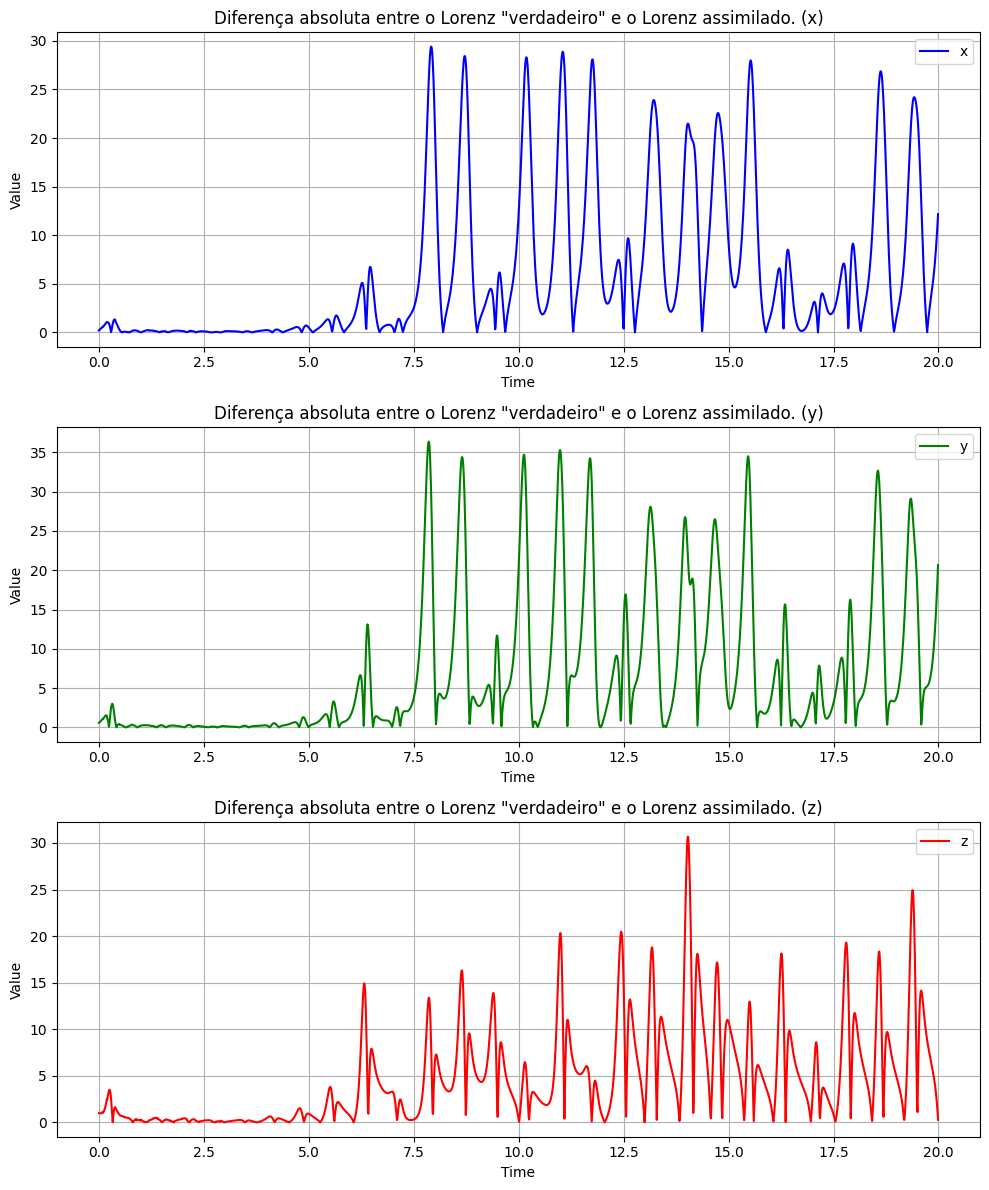

In [ ]:
# Crie a figura e os subgráficos.
fig, axs = plt.subplots(3, 1, figsize=(10, 12))
colors = ['blue', 'green', 'red']
for i, (ax, color) in enumerate(zip(axs, colors)):
    ax.plot(t_values, [np.abs(xr_values - x_values), np.abs(yr_values - y_values), np.abs(zr_values - z_values)][i], label=['x', 'y', 'z'][i], color=color)
    ax.set_title('Diferença absoluta entre o Lorenz "verdadeiro" e o Lorenz assimilado. (' + ['x', 'y', 'z'][i] + ')')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

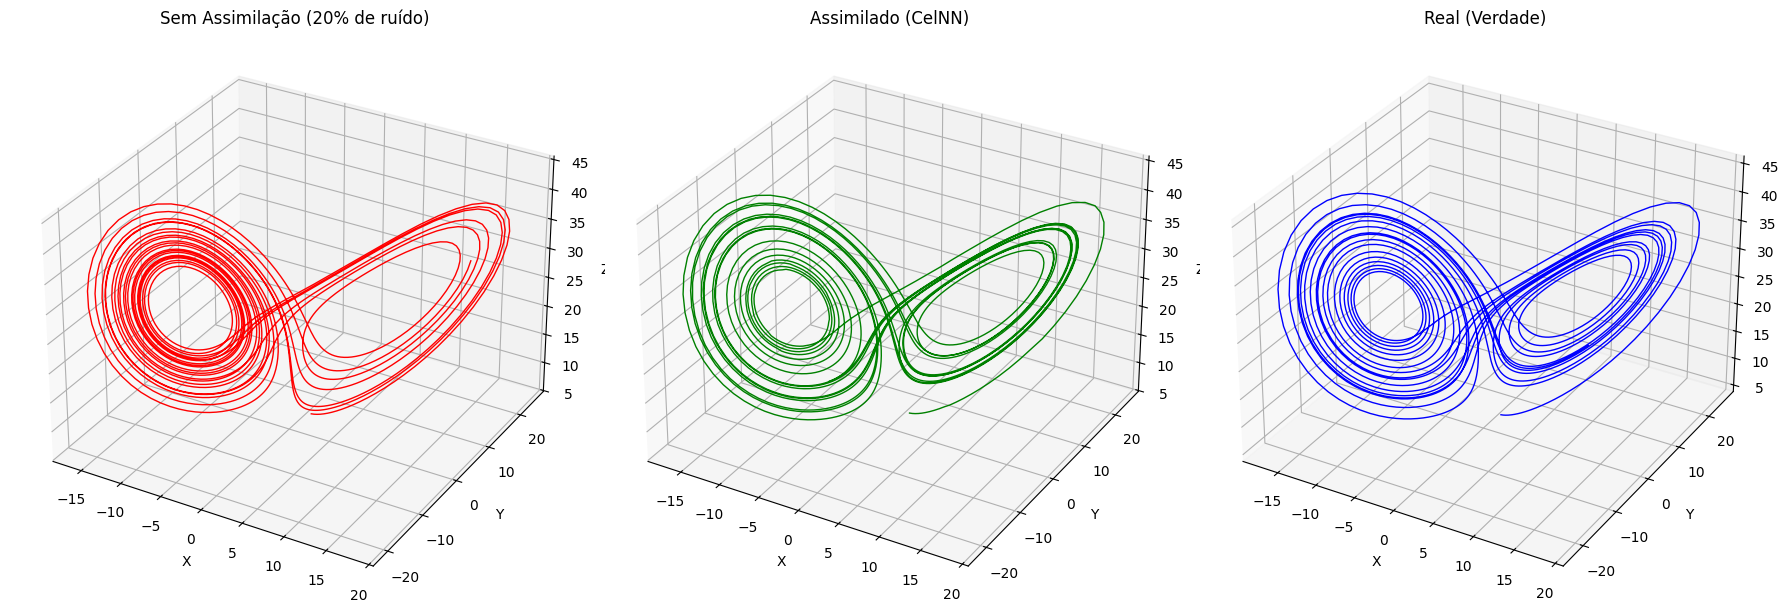

In [ ]:
# Plotagem lado a lado
fig = plt.figure(figsize=(18, 6))

# Subplot 1
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(xe_values, ye_values, ze_values, color='red', lw=1)
ax1.set_title("Sem Assimilação (20% de ruído)")
ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")

# Subplot 2
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(x_values, y_values, z_values, color='green', lw=1)
ax2.set_title("Assimilado (CelNN)")
ax2.set_xlabel("X"); ax2.set_ylabel("Y"); ax2.set_zlabel("Z")

# Subplot 3
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(xr_values, yr_values, zr_values, color='blue', lw=1)
ax3.set_title("Real (Verdade)")
ax3.set_xlabel("X"); ax3.set_ylabel("Y"); ax3.set_zlabel("Z")

plt.tight_layout()